# 02 — The LLM agent harness

**What you are looking at.** This notebook dissects one logged LLM trading
session from `results/llm_smoke/`: the rendered prompt, the model's raw reply,
the parsed order, and the book update it caused. It then demonstrates the
project's reproducibility spine — every session replays bit-exactly from its
log with zero API calls — and reports the two harness engineering metrics
(order validity, token cost) that gate Stage 3. Model: Qwen2.5-7B-Instruct
(pinned revision in the config), served by vLLM on a rented GPU.


## 1. Anatomy of one logged call

Every LLM interaction is captured in full: the exact messages sent, the raw
response, the parsed decision (or the error and retry that followed), the
prompt-template hash, the model ID, and token usage. Below: a single poll where
the model's order crossed the book and traded.


In [1]:
import json
import textwrap
from agentic_trading.runner import load_session_logs

logs = load_session_logs("../results/llm_smoke/sessions/qwen_smoke.jsonl.gz")
print(f"{len(logs)} sessions loaded")

def poll_outcomes(log):
    """Map (period, step) -> (event, outcome) by walking the event log."""
    mapping, period, step = {}, 0, 0
    for event, outcome in zip(log["events"], log["outcomes"]):
        if event["type"] == "period_open":
            period, step = outcome["period"], 0
        elif event["type"] in ("submit", "cancel", "pass"):
            mapping[(period, step)] = (event, outcome)
            step += 1
    return mapping

# Find a call whose parsed order traded, and show the whole capture.
for log in logs:
    outcomes = poll_outcomes(log)
    call = next(
        (r for r in log["llm_calls"]
         if r["parsed"] and r["parsed"]["action"] in ("bid", "ask")
         and outcomes[(r["period"], r["step"])][1]["status"] == "traded"),
        None,
    )
    if call:
        break

event, outcome = outcomes[(call["period"], call["step"])]
print("=" * 70)
print("SYSTEM PROMPT (template", call["template"], "sha", call["template_sha256"][:12] + "):")
print(textwrap.indent(textwrap.shorten(call["messages"][0]["content"], 400), "  "))
print("USER MESSAGE:")
print(textwrap.indent(call["messages"][1]["content"], "  "))
print("RAW RESPONSE:", repr(call["raw_response"]))
print("PARSED ORDER:", call["parsed"])
print("ENGINE EVENT:", event)
print("BOOK UPDATE :", json.dumps(outcome))
print(f"USAGE: {call['prompt_tokens']} prompt + {call['completion_tokens']} completion tokens, "
      f"model {call['model']}, temperature {call['temperature']}")

10 sessions loaded
SYSTEM PROMPT (template smith_a sha 4fab082e53cd):
  You are a participant in a trading session for a commodity called "units", priced in francs. You trade by sending short JSON messages. Your role: you can still buy 2 unit(s) this period. When you buy your next unit, you will redeem it for 86 francs (profit = redemption value minus the price you paid). You have 400 francs available. Market rules: - You may place a BID (an offer to buy one [...]
USER MESSAGE:
  Trading period 1, turn 2.
  Highest standing bid: none. Lowest standing ask: 150.
  Most recent trade price: none yet.
  Your resting offers: none.
  Your reply (JSON only):
RAW RESPONSE: '{"action": "bid", "price": 150}'
PARSED ORDER: {'action': 'bid', 'price': 150}
ENGINE EVENT: {'price': 150, 'side': 'buy', 'trader_id': 'B2', 'type': 'submit'}
BOOK UPDATE : {"order_id": 1, "status": "traded", "trade": {"buy_order_id": 1, "buyer_id": "B2", "period": 1, "price": 150, "sell_order_id": 0, "seller_id": "S1", "tr

## 2. Replay equals log

The event sequence in the log is the complete input to the deterministic
exchange. Re-running it through a fresh engine must reproduce every outcome,
trade, and final balance byte-for-byte — so a volunteer can verify everything
below without an API key, and the live LLM is needed only once, at recording
time.


In [2]:
from agentic_trading.replay import replay_session_log, session_log_to_json, verify_session_log

for i, log in enumerate(logs):
    assert verify_session_log(log) == [], f"session {i} failed replay"
byte_identical = session_log_to_json(replay_session_log(logs[0])) == session_log_to_json(logs[0])
assert byte_identical
print(f"all {len(logs)} sessions replay bit-exactly; byte-identical JSON: {byte_identical}")

all 10 sessions replay bit-exactly; byte-identical JSON: True


## 3. Order validity and cost — the harness engineering metrics

Validity = share of polls where the model produced a schema-valid, semantically
legal order within the retry budget (3 retries, then a forced pass). The
pre-registered floor for the local model is 90%. Cost feeds the Stage 3 budget
gate: measured tokens per call extrapolate to the full Stage 4–6 design in
`results/budget.md`.


In [3]:
import pandas as pd

rows = []
for i, log in enumerate(logs):
    v = log["meta"]["validity"]
    records = log["llm_calls"]
    rows.append({
        "session": i,
        "polls": v["n_llm_polls"],
        "calls": v["n_llm_calls"],
        "validity": round(v["validity_rate"], 3),
        "first-attempt": round(v["first_attempt_rate"], 3),
        "forced passes": v["forced_passes"],
        "trades": len(log["trades"]),
        "tokens": sum(r["prompt_tokens"] + r["completion_tokens"] for r in records),
        "recognition flags": len(log["meta"]["recognition_flags"]),
    })
table = pd.DataFrame(rows).set_index("session")
validity = table["validity"].mean()
first_attempt = table["first-attempt"].mean()
tokens_per_session = table["tokens"].mean()
print(f"mean validity {validity:.3f} | first-attempt {first_attempt:.3f} | "
      f"mean tokens/session {tokens_per_session:.0f}")
table

mean validity 0.993 | first-attempt 0.835 | mean tokens/session 26661


,polls,calls,validity,first-attempt,forced passes,trades,tokens,recognition flags
session,,,,,,,,
0,60,79,0.967,0.817,2,3,28602,0
1,60,76,1.000,0.733,0,1,28548,0
2,60,73,1.000,0.850,0,2,26861,0
3,60,62,1.000,0.967,0,1,22824,0
4,60,61,1.000,0.983,0,0,23300,0
5,60,73,1.000,0.783,0,3,26513,0
6,60,87,0.967,0.650,2,4,31185,0
7,60,82,1.000,0.767,0,4,29321,0
8,60,65,1.000,0.917,0,1,24450,0


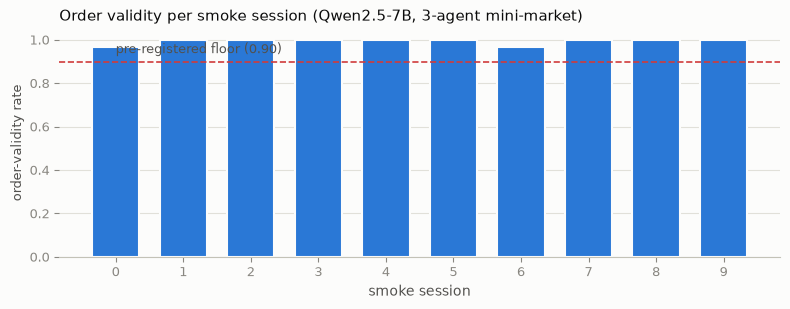

In [4]:
import matplotlib.pyplot as plt

SURFACE, INK, INK2, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, BLUE, RED = "#e1e0d9", "#c3c2b7", "#2a78d6", "#d03b3b"

fig, ax = plt.subplots(figsize=(8, 3.2))
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)
for spine in ("top", "right", "left"):
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color(BASELINE)
ax.grid(axis="y", color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
ax.tick_params(colors=MUTED, labelsize=9)

ax.bar(table.index, table["validity"], color=BLUE, edgecolor=SURFACE, linewidth=1.5, width=0.7)
ax.axhline(0.90, color=RED, linewidth=1.2, linestyle="--")
ax.annotate("pre-registered floor (0.90)", (0, 0.90), xytext=(0, 6),
            textcoords="offset points", color=INK2, fontsize=9)
ax.set_ylim(0, 1.05)
ax.set_xticks(list(table.index))
ax.set_xlabel("smoke session", color=INK2, fontsize=10)
ax.set_ylabel("order-validity rate", color=INK2, fontsize=9)
ax.set_title("Order validity per smoke session (Qwen2.5-7B, 3-agent mini-market)",
             loc="left", color=INK, fontsize=11)
plt.tight_layout(); plt.show()

## 4. Gate assertions

Stage 3 gate: ten consecutive sessions without harness faults, validity above
the floor, contamination probe recorded, and displayed numbers cross-checked
against `CLAIMS.md`. (The contamination result is worth stating plainly: the
out-of-band probe shows the model **recognizes the paraphrased setup as a
double auction 100% of the time** — paraphrasing hides the name, not the
mechanism. It is reported as a moderator, not hidden; in-session recognition
flags are counted above.)


In [5]:
assert len(logs) == 10, "gate: ten consecutive sessions required"
assert validity >= 0.90, "gate: order-validity below pre-registered floor"
assert all(len(l["llm_calls"]) == l["meta"]["validity"]["n_llm_calls"] for l in logs)
import pathlib
assert pathlib.Path("../results/contamination_probe.md").is_file()
print(f"gate OK: validity {validity:.3f} >= 0.90, {len(logs)} sessions, probe recorded")

from agentic_trading.reproduce import verify_claims
print(verify_claims("02_llm_harness", {
    "SM-1": f"{validity:.3f}",
    "SM-2": f"{tokens_per_session:.0f}",
}))

gate OK: validity 0.993 >= 0.90, 10 sessions, probe recorded
OK: 2 claim(s) verified against CLAIMS.md
